In [20]:
"""
1D Advection Equation — Discontinuous Galerkin Time Domain (DGTD) Method
=========================================================================
Solves:  ∂u/∂t + c ∂u/∂x = 0,  x ∈ [0, 1],  periodic BCs

Spatial discretisation:  nodal DG with Legendre-Gauss-Lobatto (LGL) nodes
Numerical flux:          upwind
Time integration:        low-storage 4th-order Runge–Kutta (LSRK4)

References
----------
Hesthaven & Warburton, "Nodal Discontinuous Galerkin Methods" (2008)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


# ---------------------------------------------------------------------------
# 1.  Legendre–Gauss–Lobatto (LGL) nodes and weights on [-1, 1]
# ---------------------------------------------------------------------------

def lgl_nodes_weights(N):
    """
    Return LGL nodes and weights for polynomial order N  (N+1 points).

    Uses the iterative algorithm based on the Legendre polynomial derivative.
    """
    Np = N + 1  # number of nodes

    if N == 0:
        return np.array([0.0]), np.array([2.0])

    # Initial guess: Chebyshev nodes
    xi = -np.cos(np.pi * np.arange(Np) / N).astype(float)

    P = np.zeros((Np, Np + 1))   # Legendre polynomials P_0 … P_N

    for _ in range(100):          # Newton iterations
        P[:, 0] = 1.0
        P[:, 1] = xi
        for k in range(2, Np + 1):
            P[:, k] = ((2*k - 1) * xi * P[:, k-1] - (k - 1) * P[:, k-2]) / k

        dxi = (xi * P[:, N] - P[:, N-1]) / (Np * P[:, N])
        xi  = xi - dxi
        if np.max(np.abs(dxi)) < 1e-15:
            break

    w = 2.0 / (N * Np * P[:, N]**2)
    return xi, w


# ---------------------------------------------------------------------------
# 2.  Vandermonde matrix and derivative operator on [-1, 1]
# ---------------------------------------------------------------------------

def legendre_poly(xi, N):
    """Evaluate Legendre polynomials P_0 … P_N at points xi (shape: [Np, N+1])."""
    Np = len(xi)
    P  = np.zeros((Np, N + 1))
    P[:, 0] = 1.0
    if N >= 1:
        P[:, 1] = xi
    for k in range(2, N + 1):
        P[:, k] = ((2*k - 1) * xi * P[:, k-1] - (k - 1) * P[:, k-2]) / k
    return P


def vandermonde(xi, N):
    """Vandermonde matrix V  (shape: [Np, Np]),  V_{ij} = P_j(xi_i) / ||P_j||."""
    P = legendre_poly(xi, N)
    for j in range(N + 1):
        P[:, j] *= np.sqrt((2*j + 1) / 2.0)   # orthonormal normalisation
    return P


def grad_vandermonde(xi, N):
    """Gradient Vandermonde matrix  dV/dxi."""
    Np = len(xi)
    dV = np.zeros((Np, N + 1))
    # dP_j/dxi recurrence
    P  = legendre_poly(xi, N + 1)              # need one extra
    for j in range(1, N + 1):
        dV[:, j] = np.sqrt((2*j + 1) / 2.0) * (
            (j + 1) * P[:, j+1] - (j + 1) * xi * P[:, j]
        ) / (1.0 - xi**2 + 1e-16)             # l'Hôpital near ±1 handled below
    # Fix endpoints explicitly
    for j in range(1, N + 1):
        coeff = np.sqrt((2*j + 1) / 2.0)
        # at xi = +1: dP_j/dxi = j(j+1)/2 * …  use exact formula
        # Rodrigues: P_j'(1)  = j(j+1)/2,  P_j'(-1) = (-1)^(j+1) j(j+1)/2
        dV[0,  j] = coeff * (-1)**(j+1) * j*(j+1)/2
        dV[-1, j] = coeff * j*(j+1)/2
    return dV


def differentiation_matrix(xi, N):
    """Nodal differentiation matrix  D = V^{-1} dV/dxi."""
    V  = vandermonde(xi, N)
    dV = grad_vandermonde(xi, N)
    return dV @ np.linalg.inv(V)


# ---------------------------------------------------------------------------
# 3.  Build the global DG mesh
# ---------------------------------------------------------------------------

def build_mesh(xL, xR, K, N):
    """
    Build a uniform mesh of K elements, each with N+1 LGL nodes.

    Returns
    -------
    x     : (K, Np) physical coordinates of all nodes
    J     : (K,)    Jacobian  dx/dxi = h/2  per element
    invJ  : (K,)    inverse Jacobian
    xi    : (Np,)   reference nodes
    w     : (Np,)   LGL weights
    D     : (Np,Np) differentiation matrix
    """
    Np = N + 1
    xi, w = lgl_nodes_weights(N)
    D     = differentiation_matrix(xi, N)

    h   = (xR - xL) / K
    J   = h / 2.0                    # Jacobian (same for all uniform elements)
    invJ = 1.0 / J

    # physical coordinates
    x_left = xL + np.arange(K) * h   # left edges
    x = x_left[:, None] + J * (xi[None, :] + 1.0)   # (K, Np)

    return x, J, invJ, xi, w, D


# ---------------------------------------------------------------------------
# 4.  Upwind numerical flux (scalar advection, wavespeed c)
# ---------------------------------------------------------------------------

def numerical_flux_upwind(u_minus, u_plus, c):
    """
    Upwind flux for  ∂u/∂t + c ∂u/∂x = 0.

    u_minus : state from the left element  (K,)
    u_plus  : state from the right element (K,)
    c       : advection speed (scalar)
    """
    if c >= 0:
        return c * u_minus
    else:
        return c * u_plus


# ---------------------------------------------------------------------------
# 5.  Spatial RHS operator
# ---------------------------------------------------------------------------

def rhs(u, c, invJ, D, K, N):
    """
    Compute  du/dt = L(u)  for the DG discretisation.

    Parameters
    ----------
    u   : (K, Np) solution array
    c   : advection speed
    invJ: inverse Jacobian
    D   : (Np, Np) differentiation matrix
    K   : number of elements
    N   : polynomial order

    Returns
    -------
    dudt : (K, Np)
    """
    Np = N + 1

    # --- Volume term:  - c * D u  (on reference element, scaled by invJ)
    vol = -c * invJ * (u @ D.T)      # (K, Np)

    # --- Numerical fluxes at element interfaces
    # Periodic: neighbour to the left of element k  is  (k-1) % K
    u_right = u[:, -1]               # right-boundary value of each element  (K,)
    u_left  = u[:, 0]                # left-boundary value of each element   (K,)

    # At the left face of element k:  minus = right face of (k-1), plus = left face of k
    f_left  = numerical_flux_upwind(np.roll(u_right, 1), u_left, c)   # (K,)
    # At the right face of element k: minus = right face of k, plus = left face of (k+1)
    f_right = numerical_flux_upwind(u_right, np.roll(u_left, -1), c)  # (K,)

    # Reference flux: c * u  (local interior flux)
    f_hat_left  = c * u_left   # interior flux at left  boundary of element k
    f_hat_right = c * u_right  # interior flux at right boundary of element k

    # Surface terms (lift):  (f* - f_interior) projected onto boundary
    # Left face contributes at node 0, right face at node Np-1
    surf = np.zeros((K, Np))
    surf[:, 0]   += -invJ * (f_left  - f_hat_left)    # inward normal = -1
    surf[:, -1]  +=  invJ * (f_right - f_hat_right)   # inward normal = +1

    return vol + surf


# ---------------------------------------------------------------------------
# 6.  Low-storage 4th-order Runge–Kutta (Carpenter & Kennedy, 1994)
# ---------------------------------------------------------------------------

# LSRK4 coefficients
_lsrk4_A = np.array([
    0.0,
   -567301805773.0  / 1357537059087.0,
   -2404267990393.0 / 2016746695238.0,
   -3550918686646.0 / 2091501179385.0,
   -1275806237668.0 / 842570457699.0,
])
_lsrk4_B = np.array([
    1432997174477.0 / 9575080441755.0,
    5161836677717.0 / 13612068292357.0,
    1720146321549.0 / 2090206949498.0,
    3134564353537.0 / 4481467310338.0,
    2277821191437.0 / 14882151754819.0,
])
_lsrk4_C = np.array([
    0.0,
    1432997174477.0 / 9575080441755.0,
    2526269341429.0 / 6820363962896.0,
    2006345519317.0 / 3224310063776.0,
    2802321613138.0 / 2924317926251.0,
])


def time_step_lsrk4(u, c, invJ, D, K, N, dt):
    """Advance u by one time step dt using LSRK4."""
    dU = np.zeros_like(u)
    for s in range(5):
        r  = rhs(u, c, invJ, D, K, N)
        dU = _lsrk4_A[s] * dU + dt * r
        u  = u + _lsrk4_B[s] * dU
    return u


# ---------------------------------------------------------------------------
# 7.  Main simulation
# ---------------------------------------------------------------------------

def simulate(
    c      = 1.0,         # advection speed
    xL     = 0.0,         # domain left
    xR     = 1.0,         # domain right
    K      = 10,          # number of elements
    N      = 4,           # polynomial order (Np = N+1 nodes per element)
    T      = 1.0,         # final time
    CFL    = 0.5,         # CFL number
    u0_fn  = None,        # initial condition function  u(x, t=0)
):
    """
    Run the 1-D DG advection simulation.

    Returns
    -------
    x_flat : (K*(N+1),) physical node positions
    u_flat : (K*(N+1),) solution at t = T
    err    : L2 error  (if exact solution = translation of IC)
    """
    if u0_fn is None:
        u0_fn = lambda x: np.sin(2 * np.pi * x)

    # Build mesh
    x, J, invJ, xi, w, D = build_mesh(xL, xR, K, N)

    # Initial condition
    u = u0_fn(x)   # (K, Np)
    u_history = []

    # Time step: CFL condition  dt = CFL * h / (c * (2N+1))  (spectral radius)
    h  = (xR - xL) / K
    dt = CFL * h / (abs(c) * (2 * N + 1))
    Nt = int(np.ceil(T / dt))
    dt = T / Nt     # adjust to hit T exactly

    print(f"DG advection 1D  |  K={K}, N={N}, Np={N+1}")
    print(f"dt = {dt:.3e}, Nt = {Nt}, T = {T}")

    for n in range(Nt):
        u = time_step_lsrk4(u, c, invJ, D, K, N, dt)

        if n % 100 == 0:
            u_history.append(u)

    # Exact solution (periodic, translation by c*T)
    u_exact = u0_fn((x - c * T - xL) % (xR - xL) + xL)

    # L2 error (using LGL quadrature)
    err_elem = np.sqrt(np.sum(w * J * (u - u_exact)**2, axis=1))
    err      = np.sqrt(np.sum(err_elem**2))
    print(f"L2 error at T = {T}: {err:.4e}")

    x_flat = x.ravel()
    u_flat = u.ravel()
    u_ex_f = u_exact.ravel()
    idx    = np.argsort(x_flat)

    return x_flat[idx], u_flat[idx], err, u_history



# ---------------------------------------------------------------------------
# 9.  Entry point
# ---------------------------------------------------------------------------

if __name__ == '__main__':
    # --- Single run ---
    _, _, _, u_history = simulate(
        c       = 1.0,
        xL      = 0.0,
        xR      = 1.0,
        K       = 64,           # 10 elements
        N       = 16,            # polynomial order 4  (5 nodes / element)
        T       = 1,          # one full period
        CFL     = 1e-3,
        u0_fn   = lambda x: np.exp(-100.0 * (x - 0.5)**2),
    )

DG advection 1D  |  K=64, N=16, Np=17
dt = 4.735e-07, Nt = 2112000, T = 1


/tmp/ipykernel_6161/222474863.py:202: RuntimeWarning: overflow encountered in add
  return vol + surf
/tmp/ipykernel_6161/222474863.py:238: RuntimeWarning: invalid value encountered in add
  dU = _lsrk4_A[s] * dU + dt * r
/tmp/ipykernel_6161/222474863.py:200: RuntimeWarning: invalid value encountered in subtract
  surf[:, -1]  +=  invJ * (f_right - f_hat_right)   # inward normal = +1


KeyboardInterrupt: 

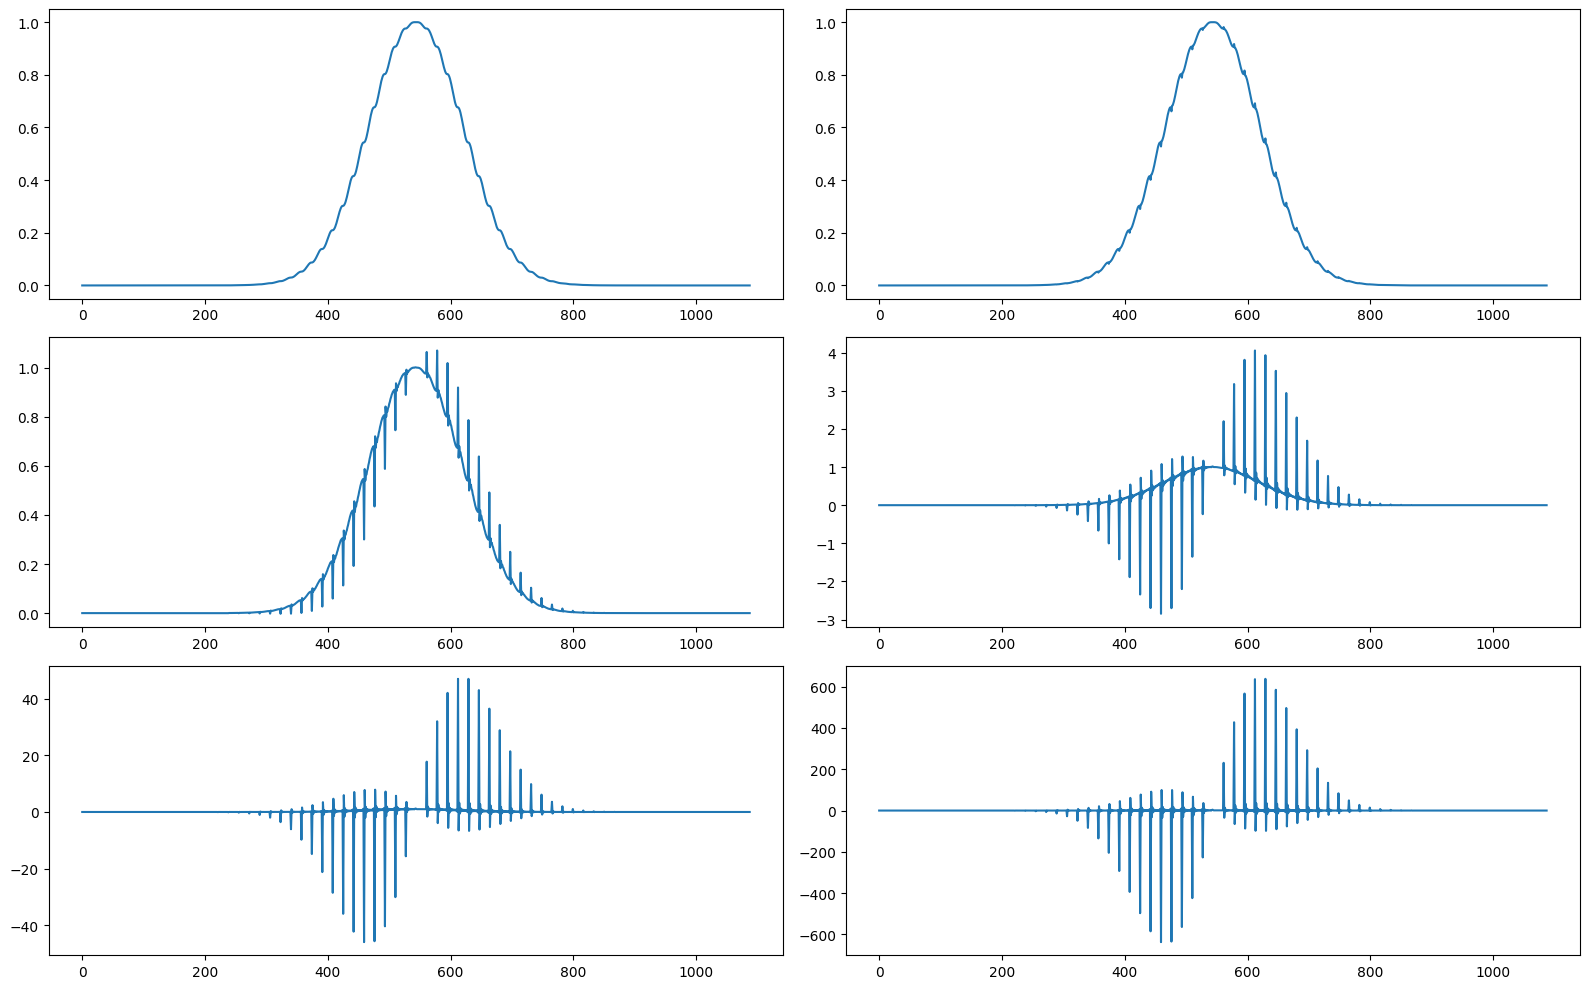

In [ ]:
total_snapshots = len(u_history)
index_list = np.linspace(0, total_snapshots // 100, 6, dtype=int)
index_list = np.linspace(200, 400, 6, dtype=int)

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    ax.plot(u_history[i].flatten())

plt.tight_layout()
plt.show()

In [ ]:
len(u_history)

4224